In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import datetime

In [25]:
demand_factors_weekly = pd.read_csv("demand factors/demand_factors_weekly.csv")
financial_factors_weekly = pd.read_csv("financial factors/weekly_financial_factors.csv")
implied_vol_indices_weekly = pd.read_csv("implied vol indices/weekly_implied_volatility_indices.csv")
brent_weekly = pd.read_csv("prices/weekly_realized_volatility_Brent.csv")
supply_factors_weekly = pd.read_csv("supply factors/weekly_crude_oil_supply.csv")
uncertainty_factors_weekly = pd.read_csv("uncertainty factors/uncertainty factors weekly.csv")

In [26]:
demand_factors_weekly = demand_factors_weekly.set_index("Date")
financial_factors_weekly = financial_factors_weekly.set_index("Date")
implied_vol_indices_weekly = implied_vol_indices_weekly.set_index("Date")
brent_weekly = brent_weekly.set_index("Date")
supply_factors_weekly = supply_factors_weekly.set_index("Date")
uncertainty_factors_weekly = uncertainty_factors_weekly.set_index("Date")

In [27]:
brent_weekly.reset_index(inplace=True)
Date = brent_weekly["Date"]
Date = pd.DataFrame(Date)
brent_weekly.drop(columns = {"Date"}, inplace = True)

In [28]:
weekly_dataset = pd.concat([demand_factors_weekly, financial_factors_weekly], axis=1)
weekly_dataset = pd.concat([weekly_dataset, implied_vol_indices_weekly], axis=1)
weekly_dataset = pd.concat([weekly_dataset, brent_weekly], axis=1)
weekly_dataset = pd.concat([weekly_dataset, supply_factors_weekly], axis=1)
weekly_dataset = pd.concat([weekly_dataset, uncertainty_factors_weekly], axis=1)

In [29]:
demand_factors_weekly.index = pd.to_datetime(demand_factors_weekly.index)
demand_factors_weekly = demand_factors_weekly[5702:]
demand_factors_weekly.reset_index(inplace = True)
demand_factors_weekly.drop( columns = {"Date"}, inplace = True)

In [30]:
week = pd.concat([Date, demand_factors_weekly], axis=1)

In [31]:
week

,Date,Imports_US,Imports_SPR,PPI_commodity,Consumption_US
0,1987-05-24,0.0,0.0,0.0,21113
1,1987-05-31,10431.0,0.0,0.0,0
2,1987-06-07,0.0,0.0,0.0,21283
3,1987-06-14,10165.0,0.0,0.0,0
4,1987-06-21,0.0,0.0,0.0,21032
...,...,...,...,...,...
2007,2025-11-09,5918.0,0.0,0.0,0
2008,2025-11-16,0.0,0.0,0.0,21281
2009,2025-11-23,5051.0,0.0,0.0,0
2010,2025-11-30,0.0,0.0,0.0,20356


In [32]:
week = pd.concat([week, brent_weekly], axis=1)

In [33]:
financial_factors_weekly.reset_index(inplace = True)
week = pd.concat([week, financial_factors_weekly.drop( columns = {"Date"})], axis=1)
implied_vol_indices_weekly.reset_index(inplace = True)
week = pd.concat([week, implied_vol_indices_weekly.drop( columns = {"Date"})], axis=1)
supply_factors_weekly.reset_index(inplace = True)
week = pd.concat([week, supply_factors_weekly.drop( columns = {"Date"})], axis=1)
uncertainty_factors_weekly.reset_index(inplace = True)  
week = pd.concat([week, uncertainty_factors_weekly.drop( columns = {"Date"})], axis=1)

In [34]:
week = week.iloc[:2012,:]
week.set_index("Date", inplace = True)
week.fillna(0, inplace = True)
week

,Imports_US,Imports_SPR,PPI_commodity,Consumption_US,RV_Brent_week,GBPUSD=X,GC=F,HG=F,JPY=X,USDEUR=X,...,Taxes,Government Spending,Health Care,National Security,Entitlement programs,Regulation,Financial Regulation,Trade Policy,"Sovereign debt, currency crises",US Policy Uncertainty Index
Date,,,,,,,,,,,,,,,,,,,,,
1987-05-24,0.0,0.0,0.0,21113.0,1.111214,0.002116,0.002295,0.003567,-0.003566,-0.004569,...,59.158157,78.819949,21.569648,35.939971,51.669244,25.926564,22.649435,24.522792,0.000000,20.749761
1987-05-31,10431.0,0.0,0.0,0.0,0.368751,0.001639,0.001490,0.003606,0.000129,-0.001498,...,59.158157,78.819949,21.569648,35.939971,51.669244,25.926564,22.649435,24.522792,0.000000,20.749761
1987-06-07,0.0,0.0,0.0,21283.0,0.902892,0.002045,-0.000083,0.007933,0.000057,-0.001713,...,59.158157,78.819949,21.569648,35.939971,51.669244,25.926564,22.649435,24.522792,0.000000,20.749761
1987-06-14,10165.0,0.0,0.0,0.0,0.938954,0.000776,0.001512,0.000141,-0.000482,-0.000755,...,59.158157,78.819949,21.569648,35.939971,51.669244,25.926564,22.649435,24.522792,0.000000,20.749761
1987-06-21,0.0,0.0,0.0,21032.0,0.941600,0.002439,0.001650,0.003213,-0.001003,-0.002393,...,27.825119,45.006556,7.346606,24.971900,16.498599,11.038210,0.000000,8.352445,25.677799,15.662639
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-11-09,5918.0,0.0,0.0,0.0,2.706120,0.000000,0.000000,0.000000,0.000000,0.000000,...,22.688072,18.899740,33.038431,11.933330,20.104687,29.463712,27.697925,9.087529,5.587532,35.861609
2025-11-16,0.0,0.0,0.0,21281.0,4.183216,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.372708,10.637952,14.979607,14.217411,17.629256,27.862758,26.879514,1.293455,1.988225,26.542126
2025-11-23,5051.0,0.0,0.0,0.0,3.461661,0.000000,0.000000,0.000000,0.000000,0.000000,...,13.372708,10.637952,14.979607,14.217411,17.629256,27.862758,26.879514,1.293455,1.988225,26.542126


In [35]:
y = pd.read_csv("prices/weekly_realized_volatility_WTI.csv")
y.set_index("Date", inplace=True)
y

,RV_WTI_week
Date,
1987-05-24,1.694678
1987-05-31,0.680510
1987-06-07,1.638344
1987-06-14,0.998714
1987-06-21,2.015020
...,...
2025-11-09,1.831674
2025-11-16,2.340390
2025-11-23,3.233335


In [36]:
import matplotlib.pyplot as plt

In [37]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [50]:
def evalutate_model(model, X_test, y_test):
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    return {"Mean Squared Error": mse, "Mean Absolute Error": mae, "R^2 Score": r2}

RIDGE

In [38]:
from sklearn.linear_model import Ridge

In [39]:
lin_model_ridge = Ridge(alpha=1.0)
lin_model_ridge.fit(week, y)
y_pred_ridge = lin_model_ridge.predict(week)
y_pred_ridge

array([1.63613607, 0.973064  , 1.40933764, ..., 3.61866337, 3.49272115,
       1.01772339], shape=(2012,))

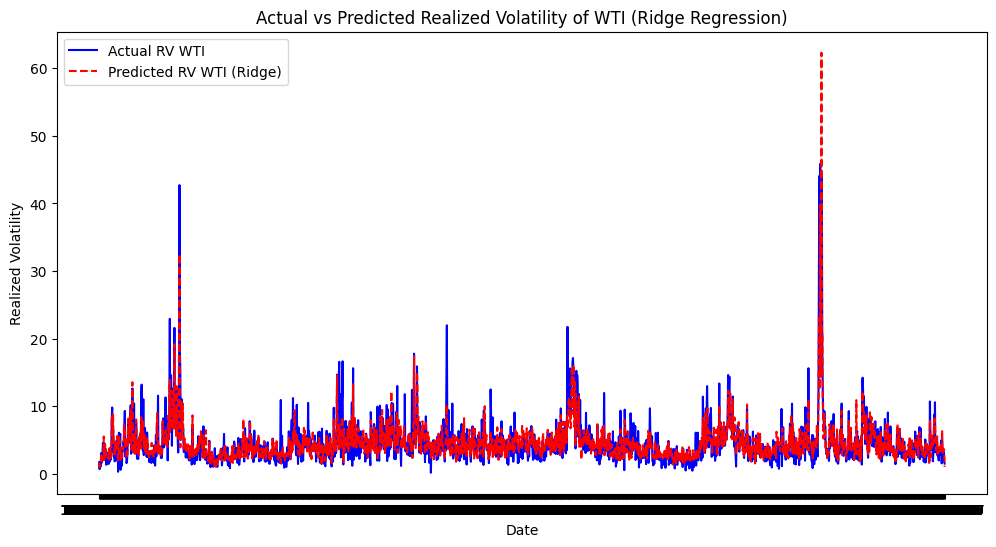

In [40]:
y_pred_ridge = pd.DataFrame(y_pred_ridge, columns=["RV_WTI_Pred_Ridge"], index=week.index)
plt.figure(figsize=(12,6))
plt.plot(y.index, y["RV_WTI_week"], label="Actual RV WTI", color="blue")
plt.plot(y_pred_ridge.index, y_pred_ridge["RV_WTI_Pred_Ridge"], label="Predicted RV WTI (Ridge)", color="red", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.title("Actual vs Predicted Realized Volatility of WTI (Ridge Regression)")
plt.legend()
plt.show()

In [55]:
metrics_ridge = evalutate_model(lin_model_ridge, week, y)
metrics_ridge

{'Mean Squared Error': 4.320826804518451,
 'Mean Absolute Error': 1.2819949150564665,
 'R^2 Score': 0.634552249806474}

LASSO

In [41]:
from sklearn.linear_model import Lasso

In [42]:
lin_model_lasso = Lasso(alpha=0.1)
lin_model_lasso.fit(week, y)
y_pred_lasso = lin_model_lasso.predict(week)
y_pred_lasso = pd.DataFrame(y_pred_lasso, columns=["RV_WTI_Pred_Lasso"], index=week.index)

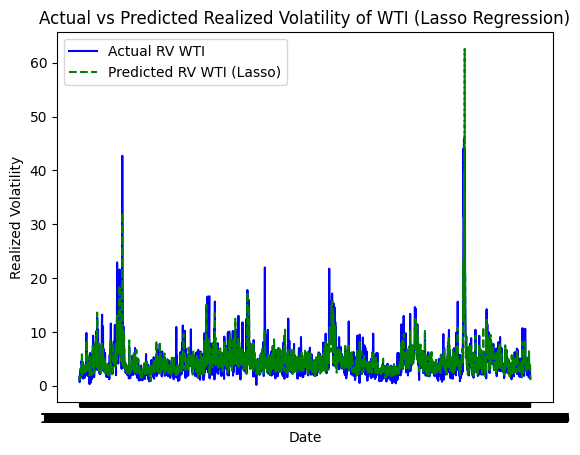

In [43]:
plt.plot(figsize = (12,6))
plt.plot(y.index, y["RV_WTI_week"], label="Actual RV WTI", color="blue")
plt.plot(y_pred_lasso.index, y_pred_lasso["RV_WTI_Pred_Lasso"], label="Predicted RV WTI (Lasso)", color="green", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.title("Actual vs Predicted Realized Volatility of WTI (Lasso Regression)")
plt.legend()
plt.show()

In [54]:
metrics_lasso = evalutate_model(lin_model_lasso, week, y)
metrics_lasso

{'Mean Squared Error': 4.397989922831866,
 'Mean Absolute Error': 1.2817515775995258,
 'R^2 Score': 0.6280259322146498}

ELASTICNET

In [44]:
from sklearn.linear_model import ElasticNet

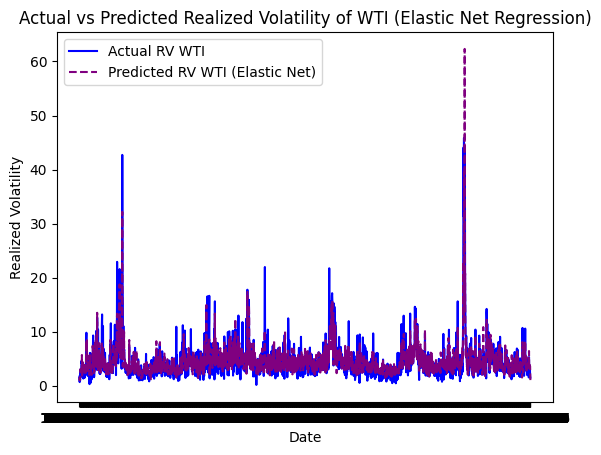

In [45]:
lin_model_elastic = ElasticNet(alpha=0.1, l1_ratio=0.5)
lin_model_elastic.fit(week, y)
y_pred_elastic = lin_model_elastic.predict(week)
y_pred_elastic = pd.DataFrame(y_pred_elastic, columns=["RV_WTI_Pred_Elastic"], index=week.index)
plt.plot(figsize = (12,6))
plt.plot(y.index, y["RV_WTI_week"], label="Actual RV WTI", color="blue")
plt.plot(y_pred_elastic.index, y_pred_elastic["RV_WTI_Pred_Elastic"], label="Predicted RV WTI (Elastic Net)", color="purple", linestyle="--")
plt.xlabel("Date")
plt.ylabel("Realized Volatility")
plt.title("Actual vs Predicted Realized Volatility of WTI (Elastic Net Regression)")
plt.legend()
plt.show()

In [53]:
metrics_elastic = evalutate_model(lin_model_elastic, week, y)
metrics_elastic

{'Mean Squared Error': 4.360890954275981,
 'Mean Absolute Error': 1.2778375348962532,
 'R^2 Score': 0.6311636961673892}

NON LINEAR MODELS

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

In [51]:
X_train, X_test, y_train, y_test = train_test_split(week, y, test_size=0.2, random_state=42)

dt = DecisionTreeRegressor(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_metrics = evalutate_model(dt, X_test, y_test)
dt_metrics

{'Mean Squared Error': 8.291925611184139,
 'Mean Absolute Error': 1.4348147660138946,
 'R^2 Score': -0.19041943895096325}

In [52]:
rf = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
rf_metrics = evalutate_model(rf, X_test, y_test)
rf_metrics

c:\Users\miche\OneDrive\Documenti\PROJECTS\crude oil forecasting\crude_oil_ml\venv\Lib\site-packages\sklearn\base.py:1363: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


{'Mean Squared Error': 3.7366113528225626,
 'Mean Absolute Error': 1.2826044931050602,
 'R^2 Score': 0.4635582856405277}

SUPPORT VECTOR MACHINE

In [56]:
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score

In [57]:
svm = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=.1)
svm.fit(X_train, y_train.values.ravel())
svm_metrics = evalutate_model(svm, X_test, y_test)
svm_metrics

{'Mean Squared Error': 7.0844079551795645,
 'Mean Absolute Error': 1.9036032668364675,
 'R^2 Score': -0.01706374836860758}

ARTIFICAL NEURAL NETWORK

In [60]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neural_network import MLPRegressor

In [61]:
model_ann = Pipeline([
    ('scaler', StandardScaler()),
    ('ann', MLPRegressor(hidden_layer_sizes=(50, 25), activation='relu', solver='adam', max_iter=1000, random_state=42))
    ])
model_ann.fit(X_train, y_train.values.ravel())
ann_metrics = evalutate_model(model_ann, X_test, y_test)
ann_metrics

{'Mean Squared Error': 5.909270176418111,
 'Mean Absolute Error': 1.6571601447341409,
 'R^2 Score': 0.15164336755105856}